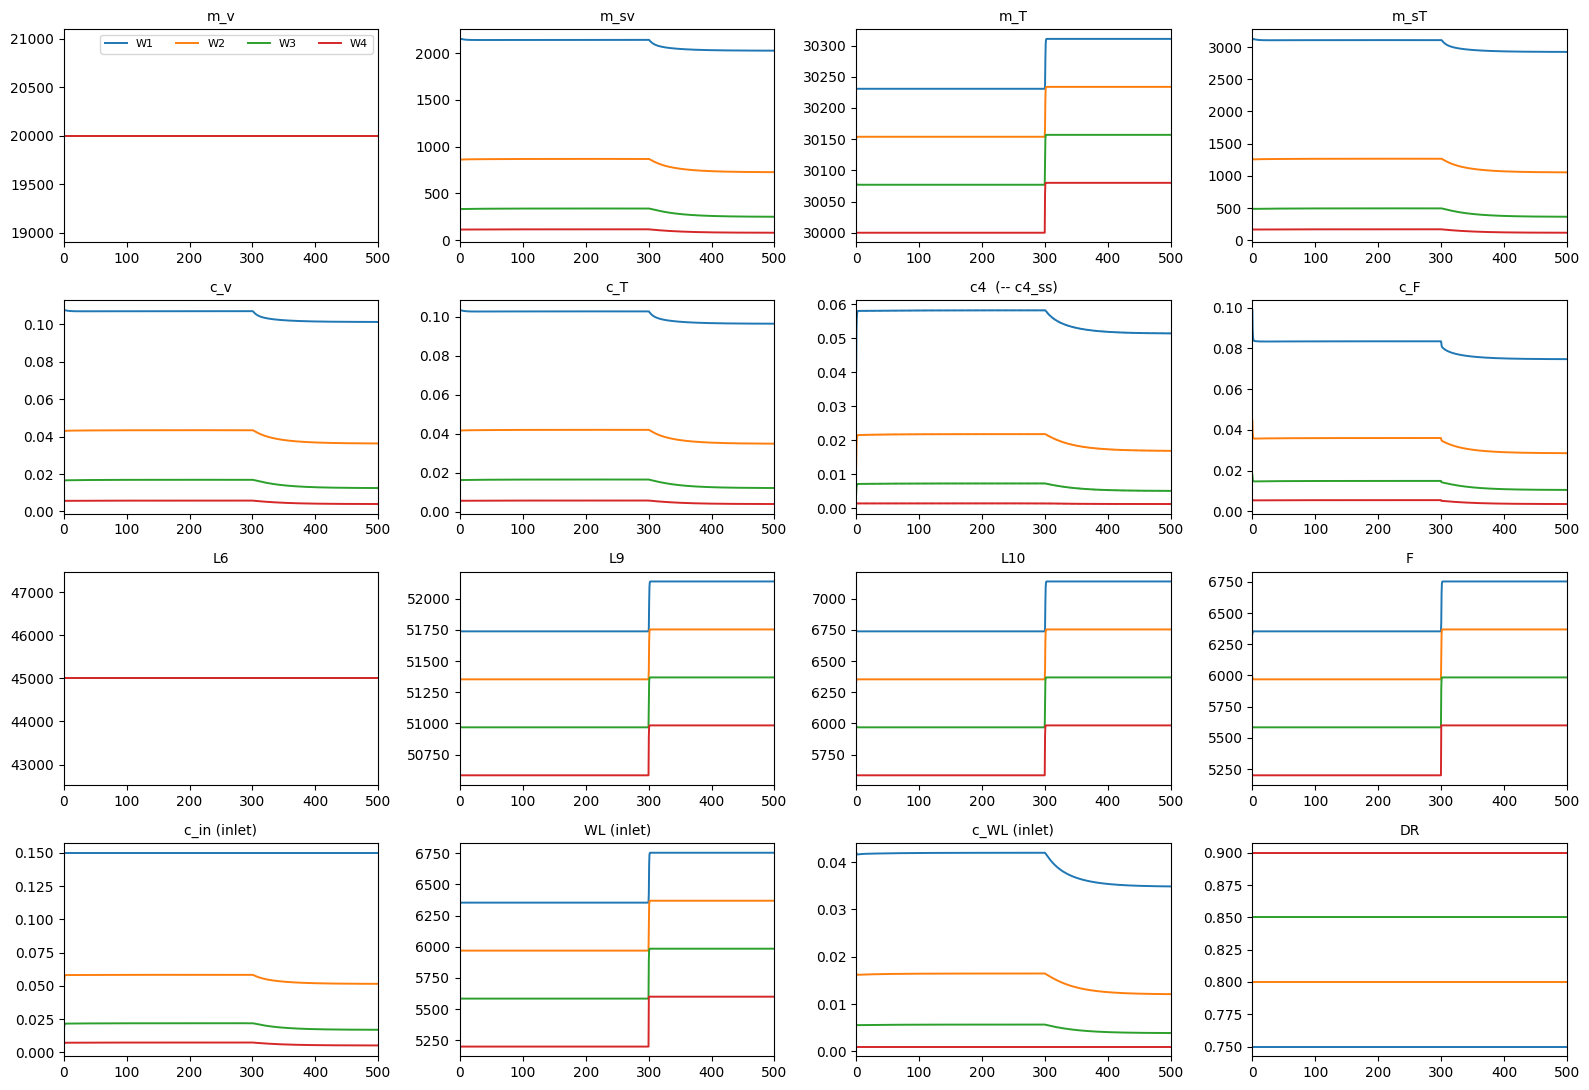

washer        m_v       m_sv        m_T       m_sT         c4        c_v        c_T        c_F         L6         L9        L10          F       c_in         WL       c_WL         DR
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
     1      2e+04       2025  3.031e+04       2925    0.05147     0.1013     0.0965    0.07468    4.5e+04  5.214e+04       7138       6754       0.15       6754    0.03487       0.75
     2      2e+04        727  3.023e+04       1054    0.01694    0.03635    0.03487    0.02854    4.5e+04  5.175e+04       6754       6369    0.05147       6369    0.01209        0.8
     3      2e+04      250.4  3.016e+04      364.5   0.005165    0.01252    0.01209     0.0105    4.5e+04  5.137e+04       6369       5985    0.01694       5985   0.003866       0.85
     4      2e+04      79.64  3.008e+04      116.3   0.001298   0.003982   0.003866  

In [5]:
import numpy as np
from scipy.integrate import solve_ivp

# inlet functions
c_in_func = lambda t: 0.15 if t < 700.0 else 0.20
WL_func = lambda t: 5200 if t < 300 else 5600
c_WL_func = lambda t: 0.001 if t < 700.0 else 0.0015
PR_func = lambda t: 600 if t < 800 else 700

# Dictionaries with operating parameters for each washer.

Washer_1 = dict(N1=0.12, N2=0.012, N3=0.10, N4=0.10, N5=0.13, DR=0.75, tau_d=0.5, m_v_sp=20000.0, m_T_sp=30000.0, Kp_v=5.0, Kp_T=5.0)
Washer_2 = dict(N1=0.12, N2=0.012, N3=0.10, N4=0.10, N5=0.13, DR=0.80, tau_d=0.5, m_v_sp=20000.0, m_T_sp=30000.0, Kp_v=5.0, Kp_T=5.0)
Washer_3 = dict(N1=0.12, N2=0.012, N3=0.10, N4=0.10, N5=0.13, DR=0.85, tau_d=0.5, m_v_sp=20000.0, m_T_sp=30000.0, Kp_v=5.0, Kp_T=5.0)
Washer_4 = dict(N1=0.12, N2=0.012, N3=0.10, N4=0.10, N5=0.13, DR=0.90, tau_d=0.5, m_v_sp=20000.0, m_T_sp=30000.0, Kp_v=5.0, Kp_T=5.0)


class Washer:

    n_states = 5
    state_names = ("m_v", "m_sv", "m_T", "m_sT", "c4")

    def __init__(self, PR, WL, N1, N2, N3, N4, N5, DR, tau_d, m_v_sp, m_T_sp, Kp_v, Kp_T):
        self.PR = PR
        self.N = (N1, N2, N3, N4, N5)
        self.DR = DR
        self.tau_d = tau_d
        self.m_v_sp = m_v_sp
        self.m_T_sp = m_T_sp
        self.Kp_v = Kp_v
        self.Kp_T = Kp_T

        # liquor-to-pulp ratio defined by consistency
        self.r = [(1.0 - n) / n for n in self.N]
        self.L1, self.L2, self.L3, self.L4, self.L5 = [PR(0) * ri for ri in self.r]

        # nominal control flows that close the steady-state balance (use nominal WL)
        self.L6_nom = self.L2 - self.L1
        self.L9_nom = (self.L2 - self.L3) + (self.L3 + WL(0) - self.L4) + (self.L4 - self.L5)

    # Provides DR value for washing section from the dynamic DR model (DR Model not yet determined, for now 
    # DR is constant)
    def dr(self, c3, c_v, c_T):
        # yet to insert dynamic DR function here
        return self.DR(c3, c_v, c_T) if callable(self.DR) else self.DR

    # outlets of each washer that feeds into neighours 
    def outlets(self, y):
        m_v, m_sv, m_T, m_sT, c4 = y
        c_T = m_sT / m_T
        L6 = max(0.0, self.L6_nom - self.Kp_v * (m_v - self.m_v_sp))
        L9 = max(0.0, self.L9_nom + self.Kp_T * (m_T - self.m_T_sp))
        L10 = L9 - L6
        return dict(c_out=c4, L10=L10, c_T=c_T)   # c_out -> downstream pulp feed; (L10,c_T) -> upstream wash liquor

    # Algebraic Equations
    def algebraic(self, t, y, inlets):

        m_v, m_sv, m_T, m_sT, c4 = y
        c_v = m_sv / m_v
        c_T = m_sT / m_T
        WL, c_WL = inlets["WL"], inlets["c_WL"]
        L1, L2, L3, L4, L5 = [self.PR(t) * ri for ri in self.r]

        # Flow control of recycle to vat (P-only for now)
        L6 = max(0.0, self.L6_nom - self.Kp_v * (m_v - self.m_v_sp))

        # Washing (wash zone)
        c3 = c_v
        F = L3 + WL - L4
        DR = self.dr(c3, c_v, c_T)
        c4_ss = (1.0 - DR) * c3 + DR * c_WL
        c_F = (L3 * c3 + WL * c_WL - L4 * c4) / F

        # Formation / dewatering drainage to the tank
        L7 = L2 - L3
        L8 = L4 - L5

        # Flow control of L9 to maintain seal-tank level (P-only for now)
        L9 = max(0.0, self.L9_nom + self.Kp_T * (m_T - self.m_T_sp))

        # Distributor
        L10 = L9 - L6
        return dict(c_v=c_v, c_T=c_T, c3=c3, c4_ss=c4_ss, c_F=c_F, L6=L6, L7=L7, L8=L8, L9=L9, L10=L10, F=F, DR=DR)

    # ODEs
    def ODEs(self, t, y, inlets):
        m_v, m_sv, m_T, m_sT, c4 = y
        c_in = inlets["c_in"]
        a = self.algebraic(t, y, inlets)
        L1, L2 = self.L1, self.L2

        # dilution vat (CSTR)
        dm_v = L1 + a['L6'] - L2
        dm_sv = L1 * c_in + a['L6'] * a['c_T'] - L2 * a['c_v']

        # filtrate/seal tank (CSTR)
        dm_T = (a['L7'] + a['F'] + a['L8']) - a['L9']
        dm_sT = a['L7'] * a['c3'] + a['F'] * a['c_F'] + a['L8'] * c4 - a['L9'] * a['c_T']

        # wash zone (drum transport delay)
        dc4 = (a['c4_ss'] - c4) / self.tau_d

        return [dm_v, dm_sv, dm_T, dm_sT, dc4]

# Connects all the washers
class WasherLine:

    def __init__(self, washers, WL, c_WL):
        self.washers = washers
        self.N = len(washers)
        self.n = washers[0].n_states
        self.fresh_WL = WL
        self.fresh_c_WL = c_WL

    # Splits string of states into a list of state arrays for each washer.
    def split(self, x):
        return [x[k * self.n:(k + 1) * self.n] for k in range(self.N)]

    # Creates the input to each washer for the next time step from the outputs of the previous time step.
    def connections(self, t, outs, c_in_func):
        
        inlets = []
        for k in range(self.N):
            # pulp side(washer 0 gets dirty pulp feed)
            c_in = c_in_func(t) if k == 0 else outs[k - 1]["c_out"]
            # liquor side: countercurrent (last washer gets fresh water)
            if k < self.N - 1:
                WL = outs[k + 1]["L10"]
                c_WL = outs[k + 1]["c_T"]
            else:
                WL = self.fresh_WL(t)
                c_WL = self.fresh_c_WL(t)
            inlets.append(dict(c_in=c_in, WL=WL, c_WL=c_WL))
        return inlets

    # Returns the ODE values for each washer in one long array that is fed to the solver
    def derivatives(self, t, x, c_in_func):
        xs = self.split(x)
        outs = [w.outlets(xk) for w, xk in zip(self.washers, xs)]      # pass 1: exports from state
        inlets = self.connections(t, outs, c_in_func)                  # pass 2: wire couplings
        dxdt = [w.ODEs(t, xk, inl) for w, xk, inl in zip(self.washers, xs, inlets)]
        return np.concatenate(dxdt)


if __name__ == "__main__":
    
    # build 4 washers from their dicts
    washer_dicts = [Washer_1, Washer_2, Washer_3, Washer_4]
    washers = [Washer(PR_func, WL_func, **d) for d in washer_dicts]

    # creates washer line (passes all washer objects and global variables)
    line = WasherLine(washers, WL_func, c_WL_func)

    # Simulate system
    t_span = (0, 500)
    t_eval = np.linspace(*t_span, 1000)

    init_c4 = [0.0405, 0.0125, 0.0043, 0.0013]
    init_m_v = [2e+04, 2e+04, 2e+04, 2e+04]
    init_m_sv = [2141, 868.7, 338.8, 116.1]
    init_m_T = [3.023e+04, 3.015e+04, 3.008e+04, 3e+04]
    init_m_sT = [3109, 1266, 495, 169.7]

    y0 = np.concatenate([[init_m_v[k], init_m_sv[k], init_m_T[k], init_m_sT[k], init_c4[k]] for k in range(len(washers))])

    sol = solve_ivp(line.derivatives, t_span, y0, args=(c_in_func,), method='LSODA', t_eval=t_eval, rtol=1e-7, atol=1e-9)
    y_end = sol.y[:, -1]


    import matplotlib.pyplot as plt

# plot dashboard
def reconstruct(line, sol, c_in_func):
    nt = sol.t.size
    fields = ["m_v","m_sv","m_T","m_sT","c4","c_v","c_T","c3","c4_ss","c_F","DR",
              "L6","L7","L8","L9","L10","F","c_in","WL","c_WL"]
    rec = [{f: np.zeros(nt) for f in fields} for _ in range(line.N)]
    for j in range(nt):
        xs = line.split(sol.y[:, j])
        outs = [w.outlets(xk) for w, xk in zip(line.washers, xs)]
        inlets = line.connections(sol.t[j], outs, c_in_func)
        for k, (w, xk, inl) in enumerate(zip(line.washers, xs, inlets)):
            a = w.algebraic(sol.t[j], xk, inl)
            r = rec[k]
            for i, name in enumerate(("m_v","m_sv","m_T","m_sT","c4")):
                r[name][j] = xk[i]
            for key in ("c_v","c_T","c3","c4_ss","c_F","DR","L6","L7","L8","L9","L10","F"):
                r[key][j] = a[key]
            r["c_in"][j], r["WL"][j], r["c_WL"][j] = inl["c_in"], inl["WL"], inl["c_WL"]
    return rec

def plot_all(line, sol, c_in_func):
    rec = reconstruct(line, sol, c_in_func)
    t = sol.t
    panels = [("m_v","m_v",None),("m_sv","m_sv",None),("m_T","m_T",None),("m_sT","m_sT",None),
              ("c_v","c_v",None),("c_T","c_T",None),("c4  (-- c4_ss)","c4","c4_ss"),("c_F","c_F",None),
              ("L6","L6",None),("L9","L9",None),("L10","L10",None),("F","F",None),
              ("c_in (inlet)","c_in",None),("WL (inlet)","WL",None),("c_WL (inlet)","c_WL",None),("DR","DR",None)]
    fig, axes = plt.subplots(4, 4, figsize=(16, 11))
    for ax, (title, f, dashed) in zip(axes.flat, panels):
        for k in range(line.N):
            ln, = ax.plot(t, rec[k][f], lw=1.4, label=f"W{k+1}")
            if dashed:
                ax.plot(t, rec[k][dashed], color=ln.get_color(), lw=1.0, ls="--", alpha=0.6)
        ax.set_title(title, fontsize=10); ax.margins(x=0)
    axes.flat[0].legend(fontsize=8, ncol=4)
    fig.tight_layout()
    return fig

plot_all(line, sol, c_in_func)
plt.show()


# table with final values
def final_table(line, sol, c_in_func):
    rec = reconstruct(line, sol, c_in_func)
    cols = ["m_v","m_sv","m_T","m_sT","c4","c_v","c_T","c_F",
            "L6","L9","L10","F","c_in","WL","c_WL","DR"]
    head = "washer " + " ".join(f"{c:>10}" for c in cols)
    print(head)
    print("-" * len(head))
    for k in range(line.N):
        vals = " ".join(f"{rec[k][c][-1]:>10.4g}" for c in cols)
        print(f"{k+1:>6} " + vals)

final_table(line, sol, c_in_func)